In [1]:
# Colab already has these, but run this if something is missing
!pip install -q scikit-learn tensorflow pandas matplotlib

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [5]:
from google.colab import files
uploaded = files.upload()   # click the "Choose Files" button and upload the CSV
# After upload, list the uploaded filename(s)
list(uploaded.keys())


Saving BankNoteAuthentication.csv to BankNoteAuthentication (2).csv


['BankNoteAuthentication (2).csv']

In [7]:
import pandas as pd

# Use the exact filename Colab showed
df = pd.read_csv('BankNoteAuthentication (2).csv')

# Quick exploration
print("Shape:", df.shape)
display(df.head())
display(df.describe().T)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['class'].value_counts())


Shape: (1372, 5)


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000



Missing values:
 variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Class distribution:
 class
0    762
1    610
Name: count, dtype: int64


In [8]:
!ls

'BankNoteAuthentication (1).csv'   BankNoteAuthentication.csv
'BankNoteAuthentication (2).csv'   sample_data


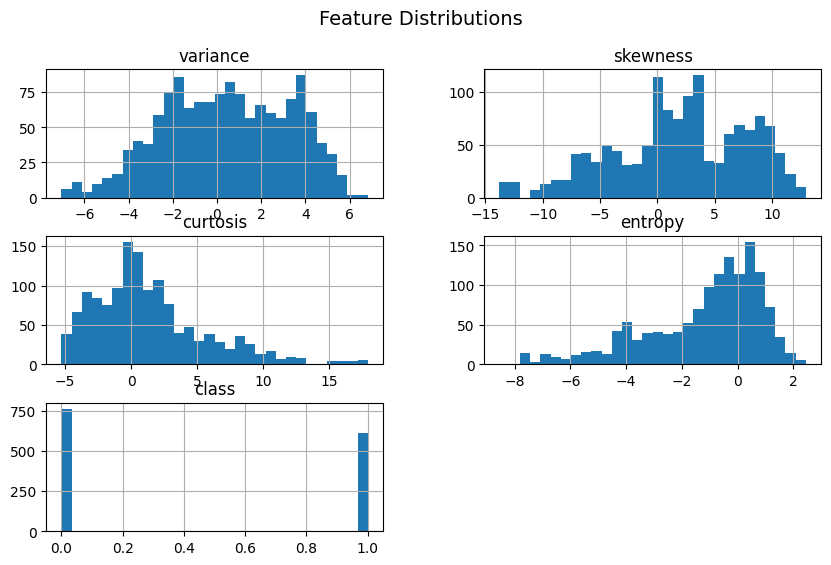

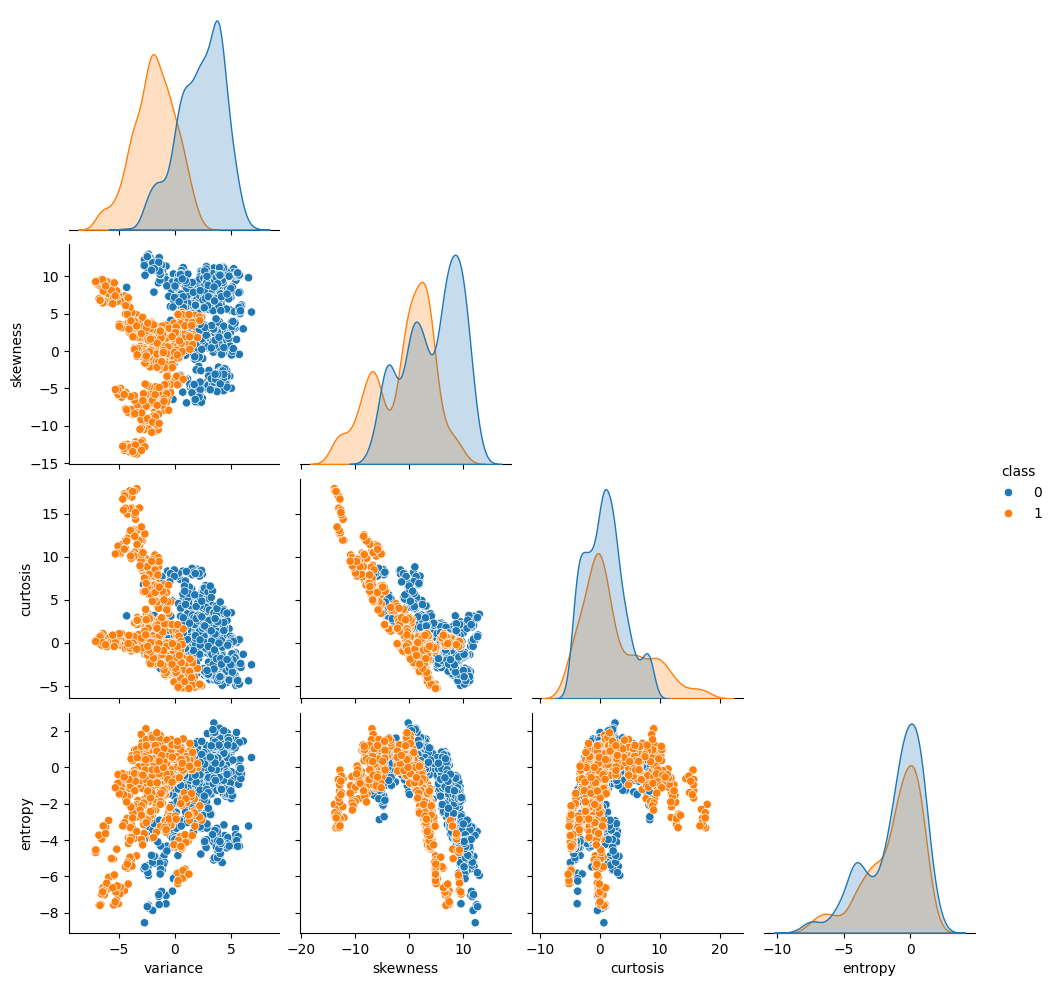

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for each feature
df.hist(bins=30, figsize=(10,6))
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

# Pairplot to see class separation (optional but nice)
sns.pairplot(df, hue='class', vars=df.columns[:-1], corner=True)
plt.show()


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and label
X = df.drop('class', axis=1).values
y = df['class'].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1097, 4)
Test shape: (275, 4)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, input_shape=(X_train.shape[1],), activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=2
)


Epoch 1/50
55/55 - 2s - 33ms/step - accuracy: 0.4447 - loss: 0.7023 - val_accuracy: 0.6000 - val_loss: 0.6509
Epoch 2/50
55/55 - 0s - 5ms/step - accuracy: 0.7993 - loss: 0.5994 - val_accuracy: 0.8273 - val_loss: 0.5583
Epoch 3/50
55/55 - 0s - 5ms/step - accuracy: 0.9019 - loss: 0.4907 - val_accuracy: 0.9136 - val_loss: 0.4361
Epoch 4/50
55/55 - 0s - 6ms/step - accuracy: 0.9361 - loss: 0.3585 - val_accuracy: 0.9273 - val_loss: 0.3034
Epoch 5/50
55/55 - 0s - 5ms/step - accuracy: 0.9567 - loss: 0.2324 - val_accuracy: 0.9591 - val_loss: 0.1987
Epoch 6/50
55/55 - 0s - 5ms/step - accuracy: 0.9726 - loss: 0.1493 - val_accuracy: 0.9636 - val_loss: 0.1372
Epoch 7/50
55/55 - 0s - 5ms/step - accuracy: 0.9806 - loss: 0.1033 - val_accuracy: 0.9682 - val_loss: 0.1032
Epoch 8/50
55/55 - 0s - 3ms/step - accuracy: 0.9818 - loss: 0.0782 - val_accuracy: 0.9818 - val_loss: 0.0822
Epoch 9/50
55/55 - 0s - 4ms/step - accuracy: 0.9840 - loss: 0.0627 - val_accuracy: 0.9818 - val_loss: 0.0679
Epoch 10/50
55/55 

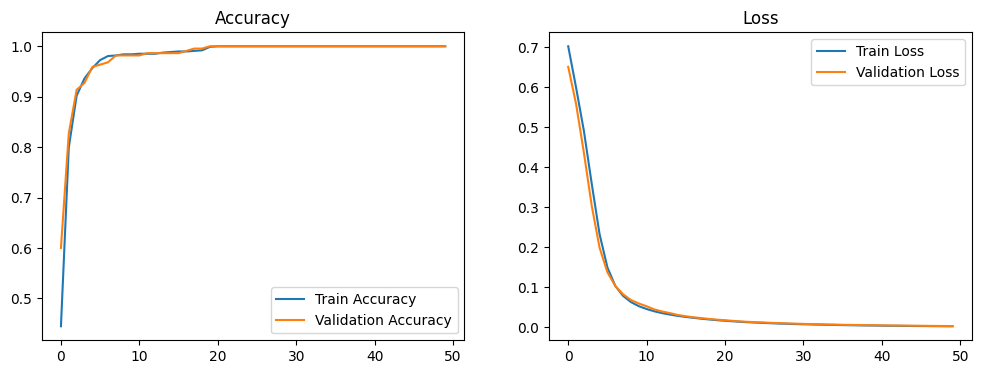

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(); plt.title("Loss")

plt.show()


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Test Accuracy: 1.0


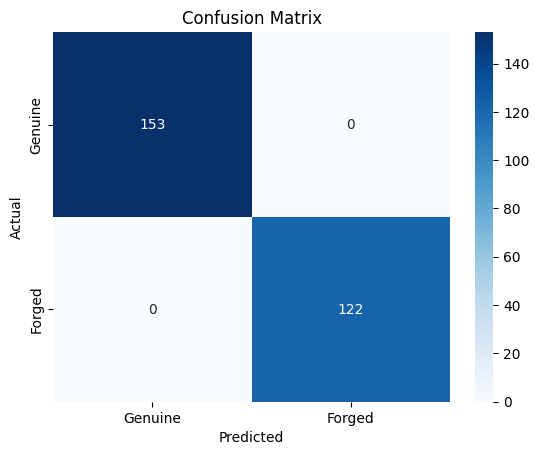

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict (probabilities → binary)
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine','Forged'], yticklabels=['Genuine','Forged'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

# Detailed report
print(classification_report(y_test, y_pred))


In [15]:
model.save('banknote_ann_model.h5')

# download to your computer
from google.colab import files
files.download('banknote_ann_model.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from sklearn.metrics import accuracy_score

# Predict on test set
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Calculate accuracy
test_acc = accuracy_score(y_test, y_pred)
print("✅ Test Accuracy: {:.2f}%".format(test_acc * 100))


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
✅ Test Accuracy: 100.00%


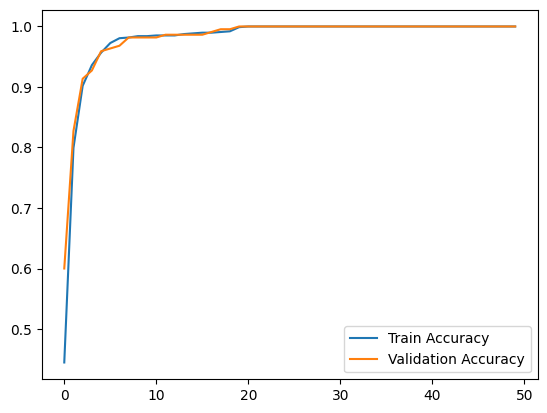

In [17]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


In [18]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('banknote_ann_model.h5')

# Display architecture
loaded_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227 (912.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)